In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
# 1. Carregar o dataset
# Substitua 'breast-cancer.data' pelo caminho do seu arquivo
df = pd.read_csv('data/class_imbalance/class_imbalance/dataset_38_sick.csv')



In [27]:
def split(X_col, y, value):
    y = np.asarray(y).ravel()
    left_mask = X_col < value
    return y[left_mask], y[~left_mask]

def split_dataset(X, target, feature_idx, threshold, return_X=True):
    left_mask = X[:, feature_idx] < threshold
    right_mask = ~left_mask
    
    # IMPORTANTE: garantir que target é tratado como dicionário internamente
    left_target = {k: v[left_mask] for k, v in target.items()}
    right_target = {k: v[right_mask] for k, v in target.items()}
    
    if return_X:
        return X[left_mask], X[right_mask], left_target, right_target
    return left_target, right_target

def xgb_criterion(y, left_indices, right_indices, l2_reg=0, gamma=0):
    """
    Calcula o ganho de estrutura do XGBoost (Gain).
    Baseia-se na primeira e segunda derivada (Gradiente e Hessiana).
    """
    # Numa implementação simplificada de MSE, G é a soma dos erros e H é o número de amostras
    # y aqui costuma representar os gradientes/resíduos
    
    G_L = np.sum(y[left_indices])
    G_R = np.sum(y[right_indices])
    H_L = len(left_indices)
    H_R = len(right_indices)
    
    term_l = (G_L ** 2) / (H_L + l2_reg)
    term_r = (G_R ** 2) / (H_R + l2_reg)
    term_all = ((G_L + G_R) ** 2) / (H_L + H_R + l2_reg)
    
    gain = 0.5 * (term_l + term_r - term_all) - gamma
    return gain



In [28]:
"""

https://github.com/rushter/MLAlgorithms/blob/master/mla/ensemble/tree.py

"""
import random

class Tree(object):
    """Recursive implementation of decision tree."""

    def __init__(self, regression=False, criterion=None, n_classes=None):
        self.regression = regression
        self.impurity = None
        self.threshold = None
        self.column_index = None
        self.outcome = None
        self.criterion = criterion
        self.loss = None
        self.n_classes = n_classes  # Only for classification

        self.left_child = None
        self.right_child = None

    @property
    def is_terminal(self):
        return not bool(self.left_child and self.right_child)

    def _find_splits(self, X):
        """Find all possible split values."""
        split_values = set()

        # Get unique values in a sorted order
        x_unique = list(np.unique(X))
        for i in range(1, len(x_unique)):
            # Find a point between two values
            average = (x_unique[i - 1] + x_unique[i]) / 2.0
            split_values.add(average)

        return list(split_values)

    def _find_best_split(self, X, target, n_features):
        """Find best feature and value for a split. Greedy algorithm."""

        # Sample random subset of features
        subset = random.sample(list(range(0, X.shape[1])), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            split_values = self._find_splits(X[:, column])
            for value in split_values:
                if self.loss is None:
                    # Random forest
                    splits = split(X[:, column], target["y"], value)
                    gain = self.criterion(target["y"], splits)
                else:
                    # Gradient boosting
                    left, right = split_dataset(
                        X, target, column, value, return_X=False
                    )
                    gain = xgb_criterion(target, left, right, self.loss)

                if (max_gain is None) or (gain > max_gain):
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _train(
        self,
        X,
        target,
        max_features=None,
        min_samples_split=10,
        max_depth=None,
        minimum_gain=0.01,
    ):
        try:
            # Exit from recursion using assert syntax
            assert X.shape[0] > min_samples_split
            assert max_depth > 0

            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None
            if self.regression:
                assert gain != 0
            else:
                assert gain > minimum_gain

            self.column_index = column
            self.threshold = value
            self.impurity = gain

            # Split dataset
            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            # Grow left and right child
            self.left_child = Tree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(
                left_X,
                left_target,
                max_features,
                min_samples_split,
                max_depth - 1,
                minimum_gain,
            )

            self.right_child = Tree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(
                right_X,
                right_target,
                max_features,
                min_samples_split,
                max_depth - 1,
                minimum_gain,
            )
        except AssertionError:
            self._calculate_leaf_value(target)

    def train(
        self,
        X,
        target,
        max_features=None,
        min_samples_split=10,
        max_depth=None,
        minimum_gain=0.01,
        loss=None,
    ):
        """Build a decision tree from training set.

        Parameters
        ----------

        X : array-like
            Feature dataset.
        target : dictionary or array-like
            Target values.
        max_features : int or None
            The number of features to consider when looking for the best split.
        min_samples_split : int
            The minimum number of samples required to split an internal node.
        max_depth : int
            Maximum depth of the tree.
        minimum_gain : float, default 0.01
            Minimum gain required for splitting.
        loss : function, default None
            Loss function for gradient boosting.
        """

        if not isinstance(target, dict):
            target = {"y": target}

        # Loss for gradient boosting
        if loss is not None:
            self.loss = loss

        if not self.regression:
            self.n_classes = len(np.unique(target["y"]))

        self._train(
            X,
            target,
            max_features=max_features,
            min_samples_split=min_samples_split,
            max_depth=max_depth,
            minimum_gain=minimum_gain,
        )

    def _calculate_leaf_value(self, targets):
        """Find optimal value for leaf."""
        if self.loss is not None:
            # Gradient boosting
            self.outcome = self.loss.approximate(targets["actual"], targets["y_pred"])
        else:
            # Random Forest
            if self.regression:
                # Mean value for regression task
                self.outcome = np.mean(targets["y"])
            else:
                # Probability for classification task
                self.outcome = (
                    np.bincount(targets["y"], minlength=self.n_classes)
                    / targets["y"].shape[0]
                )

    def predict_row(self, row):
        """Predict single row."""
        if not self.is_terminal:
            if row[self.column_index] < self.threshold:
                return self.left_child.predict_row(row)
            else:
                return self.right_child.predict_row(row)
        # For classification, outcome is a probability array; return prob of class 1
        if isinstance(self.outcome, np.ndarray):
            return self.outcome[1]
        return self.outcome

    def predict(self, X):
        result = np.zeros(X.shape[0])
        for i in range(X.shape[0]):
            result[i] = self.predict_row(X[i, :])
        return result

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
import pandas as pd
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Separar Features (X) e Alvo (y)
X = df.drop('Class', axis=1).values
y = df['Class'].values

# 3. Split de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

KeyError: 'class'

In [ ]:
# 4. Configurar o Critério (Gini por exemplo, comum em RF)
def gini_impurity(y, splits):
    """Função de critério simples para Random Forest."""
    y_left, y_right = splits
    if len(y_left) == 0 or len(y_right) == 0:
        return 0
    
    def calculate_gini(labels):
        if len(labels) == 0: return 0
        probs = np.bincount(labels) / len(labels)
        return 1 - np.sum(probs**2)
    
    n_total = len(y_left) + len(y_right)
    gini_left = calculate_gini(y_left)
    gini_right = calculate_gini(y_right)
    
    # Ganho de informação (redução da impureza)
    parent_gini = calculate_gini(np.concatenate([y_left, y_right]))
    return parent_gini - (len(y_left) / n_total * gini_left + len(y_right) / n_total * gini_right)

In [ ]:
# 5. Instanciar e Treinar a Árvore
tree = Tree(regression=False, criterion=gini_impurity)
tree.train(X_train, y_train, max_depth=5, min_samples_split=2)

# 6. Predição e Acurácia
y_pred_probs = tree.predict(X_test)
# Como a classe 1 é 'recurrence-events', se prob > 0.5, classificamos como 1
y_pred = (y_pred_probs > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)

print(f"--- Resultados ---")
print(f"Acurácia: {acc * 100:.2f}%")


--- Resultados ---
Acurácia: 93.12%


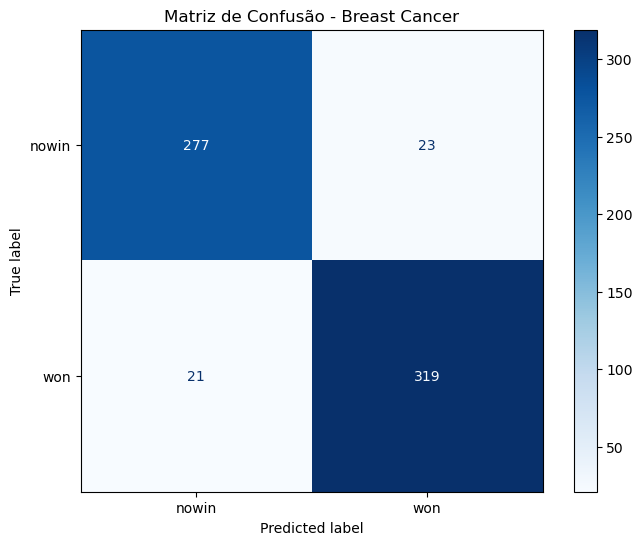


Matriz de Confusão (Valores):
[[277  23]
 [ 21 319]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Gerar a matriz de valores
cm = confusion_matrix(y_test, y_pred)

# 2. Configurar a visualização
# display_labels usa os nomes originais das classes para facilitar a leitura
labels = le.inverse_transform([0, 1]) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# 3. Plotar
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.show()

# 4. Print textual (opcional)
print("\nMatriz de Confusão (Valores):")
print(cm)